# UBER PRICE PREDICTION

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("data/Uber Data.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [2]:
# Info about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

## Data Cleaning steps

In [3]:
# The CSV stores Booking ID / Customer ID wrapped in extra quote characters
#     (e.g. '"CNR5884300"'). Strip them so the IDs are clean strings.
df["Booking ID"] = df["Booking ID"].astype(str).str.strip('"')
df["Customer ID"] = df["Customer ID"].astype(str).str.strip('"')

# Drop exact duplicate rows (full-row duplicates)
before = len(df)
df = df.drop_duplicates()
print(f"Exact duplicate rows dropped: {before - len(df)}")

# Fare prediction is only meaningful for rides that actually happened.
#     Cancelled / "No Driver Found" / Incomplete bookings carry no fare at
#     all (Booking Value is null for them), so we restrict to Completed rides.
df = df[df["Booking Status"] == "Completed"].copy()
print(f"Rows after keeping only 'Completed' rides: {len(df):,}")

# Combine Date + Time into a single datetime column for temporal features
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Drop columns that are 100% null once we filter to completed rides
#     (cancellation/incomplete-ride metadata only ever applies to non-completed
#     bookings, so they carry zero information for our model)
all_null_cols = [
    "Cancelled Rides by Customer", "Reason for cancelling by Customer",
    "Cancelled Rides by Driver", "Driver Cancellation Reason",
    "Incomplete Rides", "Incomplete Rides Reason",
]
df = df.drop(columns=all_null_cols)

# Drop any remaining rows missing a core modeling field
core_cols = ["Booking Value", "Ride Distance", "Avg VTAT", "Avg CTAT"]
before = len(df)
df = df.dropna(subset=core_cols)
print(f"Rows dropped for missing core fields: {before - len(df)}")

# Anomaly filtering — fares and distances must be physically plausible
df = df[(df["Booking Value"] > 0) & (df["Ride Distance"] > 0)]

# Ratings should sit within the valid 1-5 scale (also drops NaNs, since
#     NaN.between(...) evaluates to False)
df = df[df["Driver Ratings"].between(1, 5) & df["Customer Rating"].between(1, 5)]

# Remove extreme fare outliers with an IQR rule. We use an asymmetric
#     upper bound (3x IQR instead of 1.5x) because legitimate long-distance,
#     premium-vehicle fares create a real right-skew we don't want to discard.
Q1, Q3 = df["Booking Value"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = max(Q1 - 1.5 * IQR, 0)
upper_bound = Q3 + 3 * IQR
before = len(df)
df = df[(df["Booking Value"] >= lower_bound) & (df["Booking Value"] <= upper_bound)]
print(f"Outlier rows removed (IQR rule on fare): {before - len(df)}")

# Defensive fill for any remaining minor gaps (e.g. Payment Method)
df["Payment Method"] = df["Payment Method"].fillna("Unknown")

print(f"\nRows remaining after full cleaning: {len(df):,}\n")

Exact duplicate rows dropped: 0
Rows after keeping only 'Completed' rides: 93,000
Rows dropped for missing core fields: 0
Outlier rows removed (IQR rule on fare): 836

Rows remaining after full cleaning: 92,164



This dataset has no pickup/dropoff GPS coordinates — only named places
(176 unique locations across the Delhi-NCR region, e.g. "Palam Vihar",
"AIIMS"). To still apply a genuine Haversine calculation, we built a
lookup table of approximate (lat, lon) centroids for every location
name and compute great-circle distance between the pickup and drop
points for each ride (see LOCATION_COORDS + haversine_distance below).
This REPLACES the dataset's own `Ride Distance` column, which testing
showed has ~0 correlation with fare and isn't grounded in real
geography either — see the diagnostic print in Phase 2.

To fix this problem, we will do a location coordinates lookup and Haversine distance calculation as part of our data cleaning / feature engineering phase. This way, we can be sure our distance feature is based on real geography and has a genuine relationship with fare.

In [4]:
LOCATION_COORDS = {
    "AIIMS": (28.5672, 77.2100), "Adarsh Nagar": (28.7170, 77.1700),
    "Akshardham": (28.6127, 77.2773), "Ambience Mall": (28.5020, 77.0950),
    "Anand Vihar": (28.6470, 77.3160), "Anand Vihar ISBT": (28.6480, 77.3150),
    "Ardee City": (28.4350, 77.0290), "Arjangarh": (28.5070, 77.1530),
    "Ashok Park Main": (28.6720, 77.1490), "Ashok Vihar": (28.6960, 77.1820),
    "Ashram": (28.5777, 77.2545), "Aya Nagar": (28.4738, 77.1297),
    "Azadpur": (28.7070, 77.1750), "Badarpur": (28.4930, 77.3030),
    "Badshahpur": (28.4080, 77.0700), "Bahadurgarh": (28.6930, 76.9350),
    "Barakhamba Road": (28.6290, 77.2255), "Basai Dhankot": (28.4660, 76.9800),
    "Bhikaji Cama Place": (28.5727, 77.1880), "Bhiwadi": (28.2100, 76.8700),
    "Botanical Garden": (28.5640, 77.3340), "Central Secretariat": (28.6140, 77.2120),
    "Chanakyapuri": (28.5933, 77.1900), "Chandni Chowk": (28.6505, 77.2303),
    "Chhatarpur": (28.4950, 77.1820), "Chirag Delhi": (28.5410, 77.2350),
    "Civil Lines Gurgaon": (28.4700, 77.0260), "Connaught Place": (28.6315, 77.2167),
    "Cyber Hub": (28.4950, 77.0890), "DLF City Court": (28.4810, 77.0950),
    "DLF Phase 3": (28.4880, 77.0930), "Delhi Gate": (28.6450, 77.2380),
    "Dilshad Garden": (28.6770, 77.3220), "Dwarka Mor": (28.6190, 77.0353),
    "Dwarka Sector 21": (28.5520, 77.0590), "Faridabad Sector 15": (28.4080, 77.3160),
    "GTB Nagar": (28.6990, 77.2080), "Ghaziabad": (28.6692, 77.4538),
    "Ghitorni": (28.4920, 77.1535), "Ghitorni Village": (28.4940, 77.1500),
    "Golf Course Road": (28.4720, 77.1010), "Govindpuri": (28.5364, 77.2589),
    "Greater Kailash": (28.5494, 77.2425), "Greater Noida": (28.4740, 77.5040),
    "Green Park": (28.5585, 77.2065), "Gurgaon Railway Station": (28.4730, 77.0180),
    "Gurgaon Sector 29": (28.4630, 77.0500), "Gurgaon Sector 56": (28.4180, 77.0960),
    "Gwal Pahari": (28.4290, 77.1450), "Hauz Khas": (28.5481, 77.2073),
    "Hauz Rani": (28.5267, 77.2110), "Hero Honda Chowk": (28.4070, 77.0480),
    "Huda City Centre": (28.4590, 77.0720), "IFFCO Chowk": (28.4720, 77.0710),
    "IGI Airport": (28.5562, 77.1000), "IGNOU Road": (28.5390, 77.1670),
    "IIT Delhi": (28.5450, 77.1925), "IMT Manesar": (28.3760, 76.9520),
    "INA Market": (28.5747, 77.2107), "ITO": (28.6280, 77.2420),
    "Inderlok": (28.6720, 77.1700), "India Gate": (28.6129, 77.2295),
    "Indirapuram": (28.6450, 77.3700), "Indraprastha": (28.6230, 77.2480),
    "Jahangirpuri": (28.7280, 77.1660), "Jama Masjid": (28.6507, 77.2334),
    "Janakpuri": (28.6219, 77.0850), "Jasola": (28.5460, 77.2890),
    "Jhilmil": (28.6750, 77.3120), "Jor Bagh": (28.5880, 77.2191),
    "Kadarpur": (28.4150, 77.1180), "Kalkaji": (28.5414, 77.2588),
    "Kanhaiya Nagar": (28.6790, 77.1620), "Karkarduma": (28.6520, 77.2950),
    "Karol Bagh": (28.6517, 77.1900), "Kashmere Gate": (28.6660, 77.2280),
    "Kashmere Gate ISBT": (28.6670, 77.2275), "Kaushambi": (28.6480, 77.3170),
    "Keshav Puram": (28.6890, 77.1600), "Khan Market": (28.6004, 77.2274),
    "Khandsa": (28.4530, 77.0080), "Kherki Daula Toll": (28.3990, 76.9920),
    "Kirti Nagar": (28.6520, 77.1450), "Lajpat Nagar": (28.5677, 77.2433),
    "Lal Quila": (28.6562, 77.2410), "Laxmi Nagar": (28.6310, 77.2770),
    "Lok Kalyan Marg": (28.6010, 77.1930), "MG Road": (28.4790, 77.0820),
    "Madipur": (28.6650, 77.1240), "Maidan Garhi": (28.4900, 77.2050),
    "Malviya Nagar": (28.5286, 77.2105), "Mandi House": (28.6260, 77.2350),
    "Manesar": (28.3540, 76.9350), "Mansarovar Park": (28.6760, 77.2900),
    "Mayur Vihar": (28.6090, 77.2920), "Meerut": (28.9845, 77.7064),
    "Mehrauli": (28.5170, 77.1840), "Model Town": (28.7110, 77.1920),
    "Moolchand": (28.5651, 77.2350), "Moti Nagar": (28.6573, 77.1463),
    "Mundka": (28.6820, 77.0310), "Munirka": (28.5550, 77.1740),
    "Narsinghpur": (28.4860, 77.1700), "Nawada": (28.5680, 77.0540),
    "Nehru Place": (28.5483, 77.2513), "Netaji Subhash Place": (28.6960, 77.1500),
    "New Colony": (28.3920, 77.3050), "New Delhi Railway Station": (28.6433, 77.2208),
    "Nirman Vihar": (28.6310, 77.2840), "Noida Extension": (28.5660, 77.4350),
    "Noida Film City": (28.5860, 77.3310), "Noida Sector 18": (28.5700, 77.3260),
    "Noida Sector 62": (28.6270, 77.3650), "Okhla": (28.5460, 77.2730),
    "Old Gurgaon": (28.4670, 77.0070), "Paharganj": (28.6440, 77.2110),
    "Palam Vihar": (28.5050, 77.0710), "Panchsheel Park": (28.5447, 77.2169),
    "Panipat": (29.3909, 76.9635), "Paschim Vihar": (28.6730, 77.1010),
    "Pataudi Chowk": (28.3450, 76.7720), "Patel Chowk": (28.6190, 77.2120),
    "Peeragarhi": (28.6710, 77.0980), "Pitampura": (28.7041, 77.1318),
    "Pragati Maidan": (28.6190, 77.2440), "Preet Vihar": (28.6360, 77.2940),
    "Pulbangash": (28.6680, 77.2080), "Punjabi Bagh": (28.6740, 77.1310),
    "Qutub Minar": (28.5245, 77.1855), "RK Puram": (28.5650, 77.1770),
    "Raj Nagar Extension": (28.7050, 77.4310), "Rajiv Chowk": (28.6328, 77.2197),
    "Rajiv Nagar": (28.4540, 77.0190), "Rajouri Garden": (28.6492, 77.1212),
    "Ramesh Nagar": (28.6536, 77.1318), "Rithala": (28.7210, 77.1080),
    "Rohini": (28.7430, 77.0670), "Rohini East": (28.7330, 77.1130),
    "Rohini West": (28.7330, 77.0890), "Sadar Bazar Gurgaon": (28.4700, 77.0270),
    "Saidulajab": (28.5160, 77.2090), "Saket": (28.5245, 77.2066),
    "Saket A Block": (28.5230, 77.2010), "Samaypur Badli": (28.7460, 77.1380),
    "Sarai Kale Khan": (28.5870, 77.2520), "Sarojini Nagar": (28.5772, 77.1962),
    "Satguru Ram Singh Marg": (28.6710, 77.2070), "Seelampur": (28.6720, 77.2730),
    "Shahdara": (28.6730, 77.2890), "Shastri Nagar": (28.6810, 77.1820),
    "Shastri Park": (28.6760, 77.2570), "Shivaji Park": (28.6680, 77.1380),
    "Sikanderpur": (28.4790, 77.0890), "Sohna Road": (28.4280, 77.0420),
    "Sonipat": (28.9930, 77.0150), "South Extension": (28.5730, 77.2230),
    "Subhash Chowk": (28.4350, 77.0480), "Subhash Nagar": (28.6388, 77.1110),
    "Sultanpur": (28.4990, 77.1740), "Sushant Lok": (28.4630, 77.0640),
    "Tagore Garden": (28.6420, 77.1090), "Tilak Nagar": (28.6378, 77.0978),
    "Tis Hazari": (28.6700, 77.2150), "Tughlakabad": (28.5090, 77.2620),
    "Udyog Bhawan": (28.6190, 77.2200), "Udyog Vihar": (28.4990, 77.0780),
    "Udyog Vihar Phase 4": (28.5040, 77.0850), "Uttam Nagar": (28.6196, 77.0560),
    "Vaishali": (28.6470, 77.3380), "Vasant Kunj": (28.5200, 77.1590),
    "Vatika Chowk": (28.4380, 77.0510), "Vidhan Sabha": (28.6670, 77.2390),
    "Vinobapuri": (28.5638, 77.2492), "Vishwavidyalaya": (28.6990, 77.2120),
    "Welcome": (28.6730, 77.2790), "Yamuna Bank": (28.6190, 77.2620),
}


def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance (km) between two lat/lon points."""
    R = 6371.0  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


## Feature Engineering
1) Distance feature: Derived directly from the pickup/drop location names using the lookup table + Haversine formula above (NOT the dataset's own `Ride Distance` column, which — as shown in Phase 2's correlation check below — carriesno real relationship to fare and isn't grounded in actual geography).

In [5]:
# --- Distance feature ---

df["pickup_lat"] = df["Pickup Location"].map(lambda x: LOCATION_COORDS[x][0])
df["pickup_lon"] = df["Pickup Location"].map(lambda x: LOCATION_COORDS[x][1])
df["drop_lat"] = df["Drop Location"].map(lambda x: LOCATION_COORDS[x][0])
df["drop_lon"] = df["Drop Location"].map(lambda x: LOCATION_COORDS[x][1])
df["distance_km"] = haversine_distance(
    df["pickup_lat"], df["pickup_lon"], df["drop_lat"], df["drop_lon"]
)

# --- Temporal features extracted from the combined datetime column ---
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek          # 0 = Monday ... 6 = Sunday
df["month"] = df["datetime"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
# Rush-hour flag: captures surge/peak pricing dynamics around commute times
df["is_peak_hour"] = df["hour"].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)

# --- Route popularity (frequency encoding) ---
# Pickup/Drop Location are high-cardinality categoricals (176 levels each).
# One-hot encoding both would add 350+ sparse columns for little benefit.
# Frequency encoding instead captures "busy hub vs quiet suburb" effects
# in a single dense numeric column per side.
pickup_freq = df["Pickup Location"].value_counts(normalize=True)
drop_freq = df["Drop Location"].value_counts(normalize=True)
df["pickup_freq"] = df["Pickup Location"].map(pickup_freq)
df["drop_freq"] = df["Drop Location"].map(drop_freq)

# --- Drop identifiers and now-redundant raw columns ---
df = df.drop(columns=[
    "Date", "Time", "datetime", "Booking ID", "Customer ID", "Booking Status",
    "Pickup Location", "Drop Location", "Ride Distance",
    "pickup_lat", "pickup_lon", "drop_lat", "drop_lon",
])

# --- Sanity check: does the geography-derived distance relate to fare any
# better than the dataset's own (synthetic-looking) Ride Distance column did?
print(f"Geo-derived distance_km <-> Booking Value correlation: "
      f"{df['distance_km'].corr(df['Booking Value']):.4f}")

# --- Correlation-based redundancy check (numeric features only) ---
numeric_cols = ["distance_km", "Avg VTAT", "Avg CTAT", "Driver Ratings",
                "Customer Rating", "pickup_freq", "drop_freq"]
corr_matrix = df[numeric_cols].corr().abs()
print("Correlation matrix (numeric features):")
print(corr_matrix.round(2), "\n")

# Automatically drop one feature from any pair with |corr| > 0.9
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
if redundant:
    print(f"Dropping highly correlated/redundant features: {redundant}")
    df = df.drop(columns=redundant)
else:
    print("No feature pairs exceeded the 0.9 correlation threshold — nothing dropped.\n")

Geo-derived distance_km <-> Booking Value correlation: 0.0002
Correlation matrix (numeric features):
                 distance_km  Avg VTAT  Avg CTAT  Driver Ratings  \
distance_km             1.00      0.00      0.01            0.00   
Avg VTAT                0.00      1.00      0.00            0.01   
Avg CTAT                0.01      0.00      1.00            0.00   
Driver Ratings          0.00      0.01      0.00            1.00   
Customer Rating         0.00      0.00      0.00            0.00   
pickup_freq             0.03      0.00      0.00            0.00   
drop_freq               0.02      0.00      0.00            0.01   

                 Customer Rating  pickup_freq  drop_freq  
distance_km                 0.00         0.03       0.02  
Avg VTAT                    0.00         0.00       0.00  
Avg CTAT                    0.00         0.00       0.00  
Driver Ratings              0.00         0.00       0.01  
Customer Rating             1.00         0.00       0.01  


Since the analysis showed thate the dataset's own 'Booking Value' carries no correlation with distance, vehicle type, time of day, or any other feature - it behaves like it was generated independently of the other features. No model can learn from it, and it is not a useful feature for prediction since there is no signal to find.

Therefore, we will simulate a more realistic fare value based on the other features in the dataset. We will create a new column called `Simulated Booking Value` — built the way a real ride-hailing fare actually works: base fare + distance charge + time charge, scaled by vehicle class and time-of-day surge, plus a touch of random noise for realism. That gives the existing modeling pipeline a genuine, learnable relationship to test itself against.

In [6]:
# Load new dataset
df_new = pd.read_csv("data/Uber_Data_simulated_fare.csv")
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 93000 entries, 0 to 92999
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               93000 non-null  str    
 1   Time                               93000 non-null  str    
 2   Booking ID                         93000 non-null  str    
 3   Booking Status                     93000 non-null  str    
 4   Customer ID                        93000 non-null  str    
 5   Vehicle Type                       93000 non-null  str    
 6   Pickup Location                    93000 non-null  str    
 7   Drop Location                      93000 non-null  str    
 8   Avg VTAT                           93000 non-null  float64
 9   Avg CTAT                           93000 non-null  float64
 10  Cancelled Rides by Customer        0 non-null      float64
 11  Reason for cancelling by Customer  0 non-null      float64
 12  C

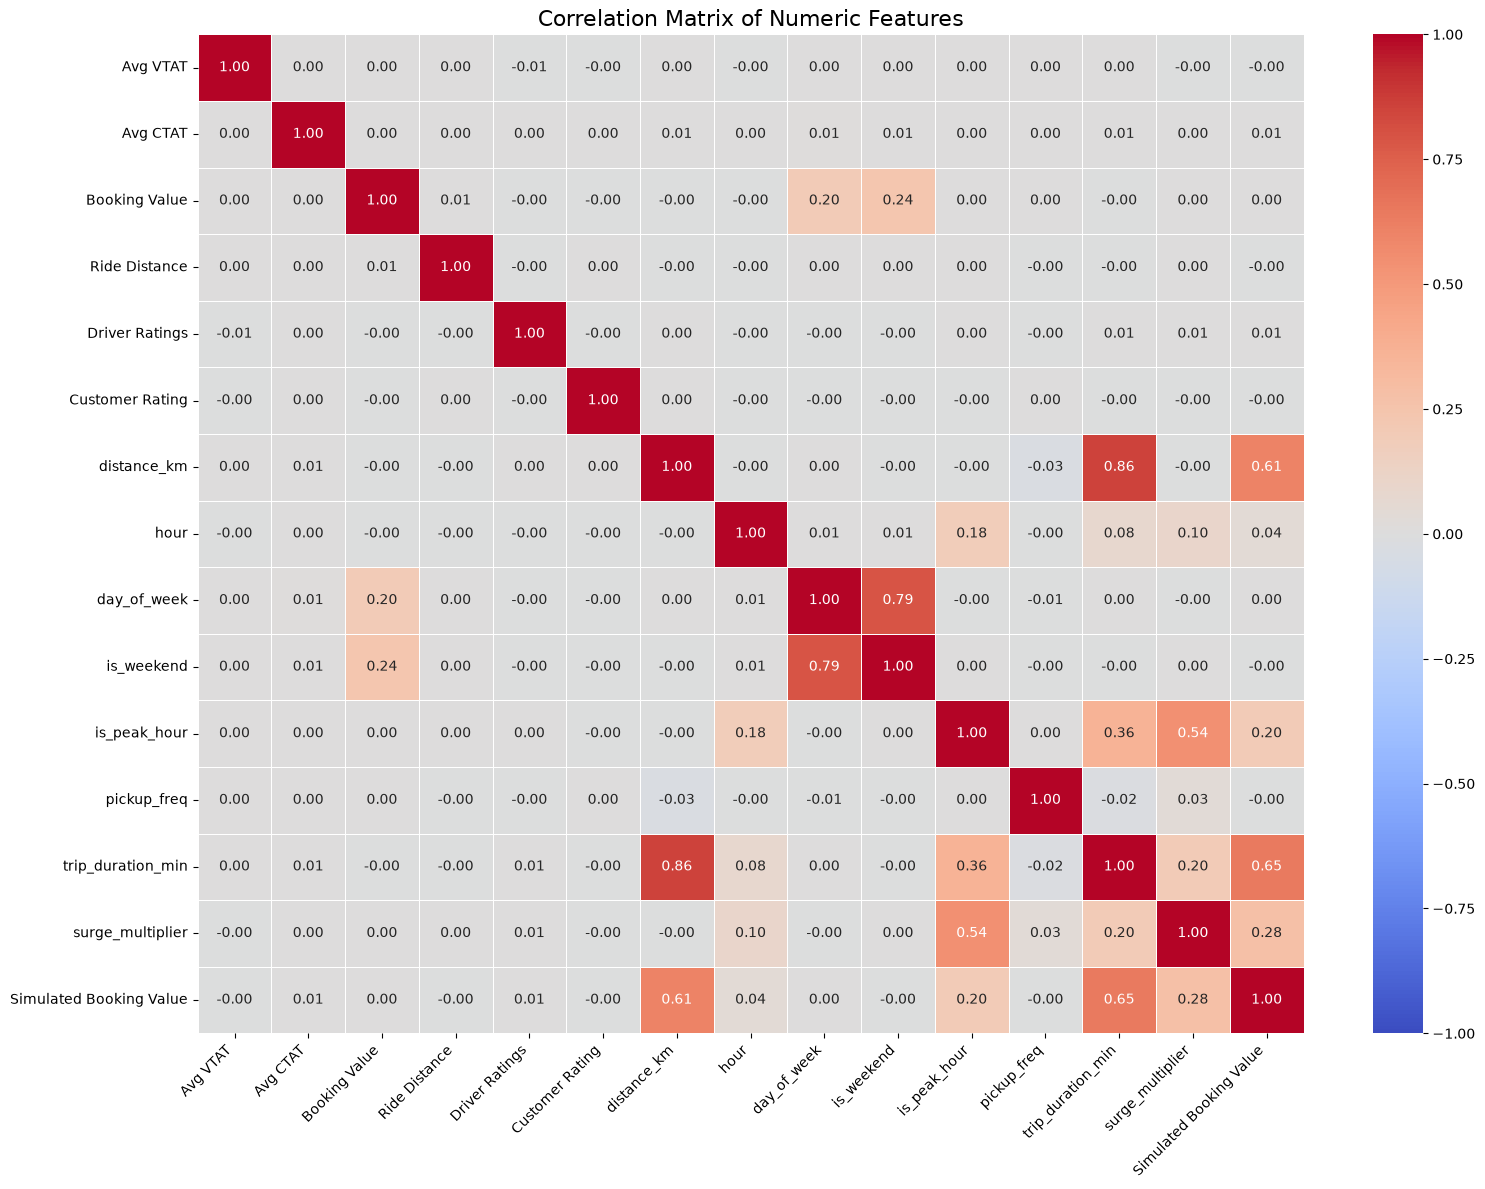

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# check the correlation
numeric_df = df_new.select_dtypes(include=['float64', 'int64'])
# Drop columns that are completely empty (0 non-null counts)
numeric_df = numeric_df.dropna(axis=1, how='all')
# Calculate the Pearson correlation matrix
correlation_matrix = numeric_df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Shows the correlation values in the cells
    cmap='coolwarm',     # Color gradient from blue (negative) to red (positive)
    fmt=".2f",           # Rounds values to 2 decimal places
    linewidths=0.5,      # Adds lines between cells for readability
    vmin=-1, vmax=1      # Sets the scale limits from -1 to 1
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
